# Empirical Bayes for Automatic Hyperparameter Tuning

When using `NormalRegressor` in a contextual bandit, you must specify two hyperparameters:

- **`alpha`** (prior precision): Controls how strongly the model regularizes its coefficients toward zero. Too high means the model is slow to learn; too low means it overfits early data.
- **`beta`** (noise precision): Controls how much the model trusts individual observations. Too high means updates are too aggressive; too low means the model learns too slowly.

In practice, these are rarely known upfront. Misspecified hyperparameters lead to poor exploration-exploitation tradeoffs: the bandit either over-explores (wasting pulls on suboptimal arms) or under-explores (locking in on a suboptimal arm too early).

`EmpiricalBayesNormalRegressor` solves this by automatically tuning `alpha` and `beta` via **evidence maximization** (MacKay's update rules). Each time the model is updated, it adjusts the hyperparameters to maximize the marginal likelihood of the observed data.

In this notebook, we demonstrate that:
1. A `NormalRegressor` with badly misspecified hyperparameters suffers high regret
2. An `EmpiricalBayesNormalRegressor` initialized with the **same bad hyperparameters** recovers and matches or beats a well-tuned baseline
3. Adding a small **decay rate** as insurance against non-stationarity doesn't hurt EB's ability to track good hyperparameters

## Setup: Linear Reward Oracle

We simulate a contextual bandit where the expected reward for each arm is a linear function of user features. The oracle knows the true coefficients and noise level; the bandit agents do not.

We use a **shared model** (`LipschitzContextualAgent`) so that all arms contribute data to a single learner. This is essential for empirical Bayes — the hyperparameter updates need sufficient data from every observation, not just the 1-in-K observations that happen to land on a particular arm.

In [1]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray

rng = np.random.default_rng(42)

# True coefficients for 4 arms (intercept + 3 features)
TRUE_COEFS = np.array([
    [1.0, 0.5, -0.3, 0.2],   # arm 0: moderate baseline, feature-dependent
    [-0.5, 0.8, 0.1, -0.4],  # arm 1: low baseline, strong feature 1 effect
    [0.3, -0.2, 0.6, 0.1],   # arm 2: moderate, strong feature 2 effect
    [0.0, 0.1, 0.1, 0.7],    # arm 3: low baseline, strong feature 3 effect
])

N_ARMS = TRUE_COEFS.shape[0]
FEATURE_NAMES = ["intercept", "feature_1", "feature_2", "feature_3"]

# True noise standard deviation (unknown to the agents)
TRUE_NOISE_STD = 0.5


class LinearRewardOracle:
    """Generates linear rewards with Gaussian noise."""

    def __init__(self, coefs: NDArray[np.float64], noise_std: float):
        self.coefs = coefs
        self.noise_std = noise_std
        self.context: NDArray[np.float64] = np.zeros(coefs.shape[1])

    def set_context(self, context: NDArray[np.float64]) -> None:
        self.context = context

    def expected_reward(self, arm_idx: int) -> float:
        return float(self.context @ self.coefs[arm_idx])

    def best_expected_reward(self) -> float:
        return float(np.max(self.context @ self.coefs.T))

    def generate_reward(self, arm_idx: int, rng: np.random.Generator) -> float:
        return self.expected_reward(arm_idx) + rng.normal(0, self.noise_std)


oracle = LinearRewardOracle(TRUE_COEFS, TRUE_NOISE_STD)

## Defining the Arms and Agents

We compare four agents, all using Thompson Sampling with a **shared model** (`LipschitzContextualAgent`). The arm featurizer creates **block-sparse** features: for arm $a$, the user features are placed in the $a$-th block of a $K \times d$-dimensional vector (zeros elsewhere). This lets the shared model learn arm-specific coefficients — equivalent to a disjoint model, but with a single set of hyperparameters.

1. **Default `NormalRegressor`** (`alpha=1.0, beta=1.0`) — reasonable hyperparameters that happen to work okay
2. **Misspecified `NormalRegressor`** (`alpha=10.0, beta=0.1`) — tight prior and underestimated noise precision; the model barely updates from data
3. **`EmpiricalBayesNormalRegressor`** (`alpha=10.0, beta=0.1`) — same bad initialization, but EB corrects the hyperparameters automatically
4. **`EmpiricalBayesNormalRegressor` + decay** (`learning_rate=0.999`) — same as above, but with a small decay applied as a defensive measure against potential non-stationarity. In practice you rarely know whether the environment is stationary, so a gentle decay is a sensible default.

In [2]:
from bayesianbandits import (
    Arm,
    NormalRegressor,
    EmpiricalBayesNormalRegressor,
    FunctionArmFeaturizer,
    LipschitzContextualAgent,
    ThompsonSampling,
)

N_FEATURES = len(FEATURE_NAMES)


def block_sparse_featurizer(X, action_tokens):
    """Create block-sparse features: arm a gets user features in the a-th block.

    For arm a with user features x ∈ R^d, the output is:
        z_a = [0...0 | x | 0...0] ∈ R^(K*d)
    where x occupies positions [a*d : (a+1)*d].

    This lets a single shared model learn arm-specific coefficients.
    """
    n_contexts = X.shape[0]
    n_arms = len(action_tokens)
    # Output shape: (n_contexts, K*d, n_arms) — one feature vector per (context, arm) pair
    result = np.zeros((n_contexts, N_ARMS * N_FEATURES, n_arms))
    for i, token in enumerate(action_tokens):
        start = token * N_FEATURES
        end = start + N_FEATURES
        result[:, start:end, i] = X
    return result


arm_featurizer = FunctionArmFeaturizer(block_sparse_featurizer)


def make_agent(learner, seed):
    """Create a LipschitzContextualAgent with the given shared learner."""
    return LipschitzContextualAgent(
        arms=[Arm(action_token=i) for i in range(N_ARMS)],
        learner=learner,
        policy=ThompsonSampling(),
        arm_featurizer=arm_featurizer,
        random_seed=np.random.default_rng(seed),
    )


# Agent 1: Default NormalRegressor (reasonable hyperparameters)
default_agent = make_agent(NormalRegressor(alpha=1.0, beta=1.0), seed=0)

# Agent 2: Misspecified NormalRegressor (bad hyperparameters)
misspecified_agent = make_agent(NormalRegressor(alpha=10.0, beta=0.1), seed=0)

# Agent 3: Empirical Bayes (same bad initial hyperparameters, but self-correcting)
eb_agent = make_agent(EmpiricalBayesNormalRegressor(alpha=10.0, beta=0.1), seed=0)

# Agent 4: Empirical Bayes + decay (defensive against non-stationarity)
eb_decay_agent = make_agent(
    EmpiricalBayesNormalRegressor(alpha=10.0, beta=0.1, learning_rate=0.999),
    seed=0,
)

## Running the Simulation

We run all four agents for 5000 rounds on the same sequence of contexts. Each round, we sample a random user context, let each agent choose an arm, observe the reward, and update the agent.

In [3]:
N_ROUNDS = 5000

# Pre-generate contexts so all agents see the same sequence
context_rng = np.random.default_rng(123)
contexts = np.column_stack([
    np.ones(N_ROUNDS),                          # intercept
    context_rng.standard_normal((N_ROUNDS, 3)),  # 3 user features
])

agents = {
    "Default (α=1, β=1)": default_agent,
    "Misspecified (α=10, β=0.1)": misspecified_agent,
    "EB (α=10, β=0.1)": eb_agent,
    "EB + decay (lr=0.999)": eb_decay_agent,
}

# Track results
optimal_rewards = np.empty(N_ROUNDS)
expected_rewards = {name: np.empty(N_ROUNDS) for name in agents}

# Track EB hyperparameters over time (both EB agents)
eb_alpha_history = []
eb_beta_history = []
eb_decay_alpha_history = []
eb_decay_beta_history = []

for t in range(N_ROUNDS):
    context = contexts[[t]]  # shape (1, 4)
    oracle.set_context(contexts[t])
    optimal_rewards[t] = oracle.best_expected_reward()

    for name, agent in agents.items():
        reward_rng = np.random.default_rng(t * 1000 + hash(name) % 1000)

        (action,) = agent.pull(context)
        arm_idx = action
        expected_rewards[name][t] = oracle.expected_reward(arm_idx)

        reward = oracle.generate_reward(arm_idx, reward_rng)
        agent.select_for_update(arm_idx).update(context, np.array([reward]))

    # Record EB hyperparameters from the shared learners
    eb_learner = eb_agent.learner
    eb_alpha_history.append(eb_learner.alpha)
    eb_beta_history.append(eb_learner.beta)

    eb_decay_learner = eb_decay_agent.learner
    eb_decay_alpha_history.append(eb_decay_learner.alpha)
    eb_decay_beta_history.append(eb_decay_learner.beta)

    if (t + 1) % 1000 == 0:
        print(f"Round {t + 1}/{N_ROUNDS}")

print("Simulation complete.")

Round 1000/5000


Round 2000/5000


Round 3000/5000


Round 4000/5000


Round 5000/5000
Simulation complete.


## Results: Cumulative Regret

Cumulative regret measures the total cost of not always choosing the best arm. Lower is better. A well-calibrated agent should achieve sublinear regret (the curve flattens over time).

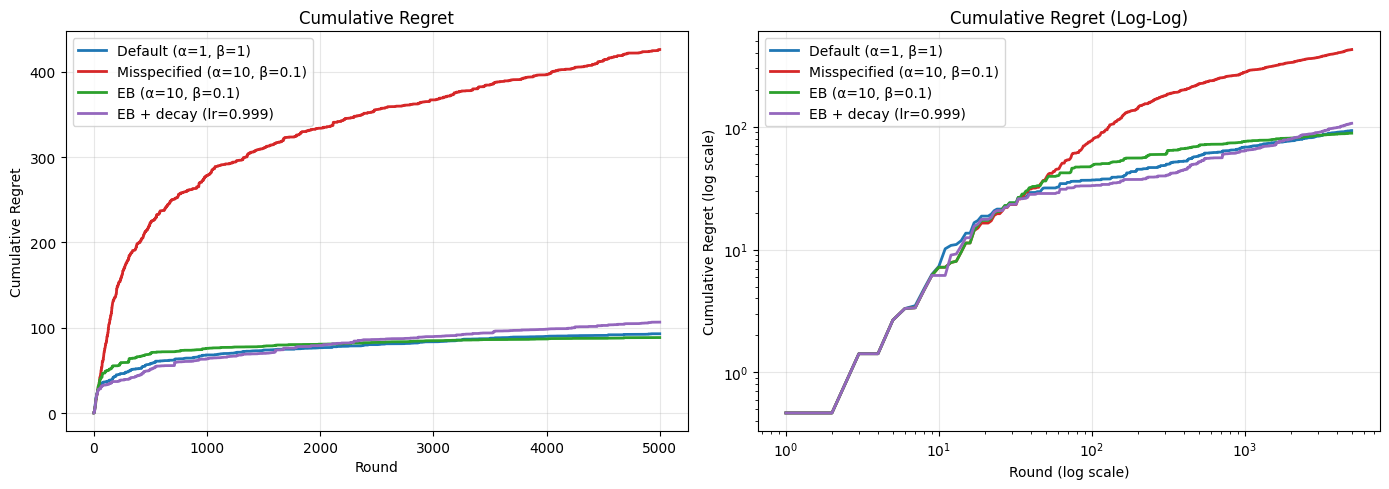

Final cumulative regret:
  Default (α=1, β=1): 93.1
  Misspecified (α=10, β=0.1): 425.9
  EB (α=10, β=0.1): 88.7
  EB + decay (lr=0.999): 106.8


In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "Default (α=1, β=1)": "C0",
    "Misspecified (α=10, β=0.1)": "C3",
    "EB (α=10, β=0.1)": "C2",
    "EB + decay (lr=0.999)": "C4",
}

for name in agents:
    regret = np.cumsum(optimal_rewards - expected_rewards[name])
    ax1.plot(regret, label=name, linewidth=2, color=colors[name])

ax1.set_xlabel("Round")
ax1.set_ylabel("Cumulative Regret")
ax1.set_title("Cumulative Regret")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log-log scale to see sublinear behavior
rounds = np.arange(1, N_ROUNDS + 1)
for name in agents:
    regret = np.cumsum(optimal_rewards - expected_rewards[name])
    ax2.loglog(rounds, regret, label=name, linewidth=2, color=colors[name])

ax2.set_xlabel("Round (log scale)")
ax2.set_ylabel("Cumulative Regret (log scale)")
ax2.set_title("Cumulative Regret (Log-Log)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final regret values
print("Final cumulative regret:")
for name in agents:
    regret = np.cumsum(optimal_rewards - expected_rewards[name])[-1]
    print(f"  {name}: {regret:.1f}")

**What to notice:**

- All agents eventually achieve sublinear regret — given enough data, the likelihood always overwhelms the prior. But the **misspecified agent** (red) takes *much* longer to get there. Its tight prior (`alpha=10`) and low noise precision (`beta=0.1`) mean the model needs far more observations before the data dominates, accumulating substantial regret in the meantime.
- The **default agent** (blue) does well with its reasonable hyperparameters, reaching the sublinear regime quickly.
- **EB** (green) starts from the same bad hyperparameters as the misspecified agent, yet recovers quickly and actually *outperforms* the default — evidence maximization finds hyperparameters better suited to this problem than the hand-picked defaults.
- **EB + decay** (purple) tracks closely behind EB. The small regret premium (~20 extra) is the cost of maintaining a wider posterior via decay. In a stationary environment this is pure insurance; if the environment were to shift, this agent would adapt while the others would not.

## Hyperparameter Evolution

The key advantage of empirical Bayes is visible in how the hyperparameters evolve. Despite starting from badly misspecified values (`alpha=10`, `beta=0.1`), both EB agents quickly adjust them toward values that better reflect the data.

The true noise precision is `beta_true = 1 / noise_std^2 = 4.0`. We expect both EB agents' `beta` to move toward this value. The optimal `alpha` depends on the signal strength and is harder to know in advance — this is exactly why automatic tuning is valuable.

The EB + decay agent tracks similar hyperparameters to the no-decay variant. Decay slightly widens the posterior (less certainty from older data), which the MacKay updates absorb gracefully. This is the payoff: you get insurance against non-stationarity without sacrificing hyperparameter quality.

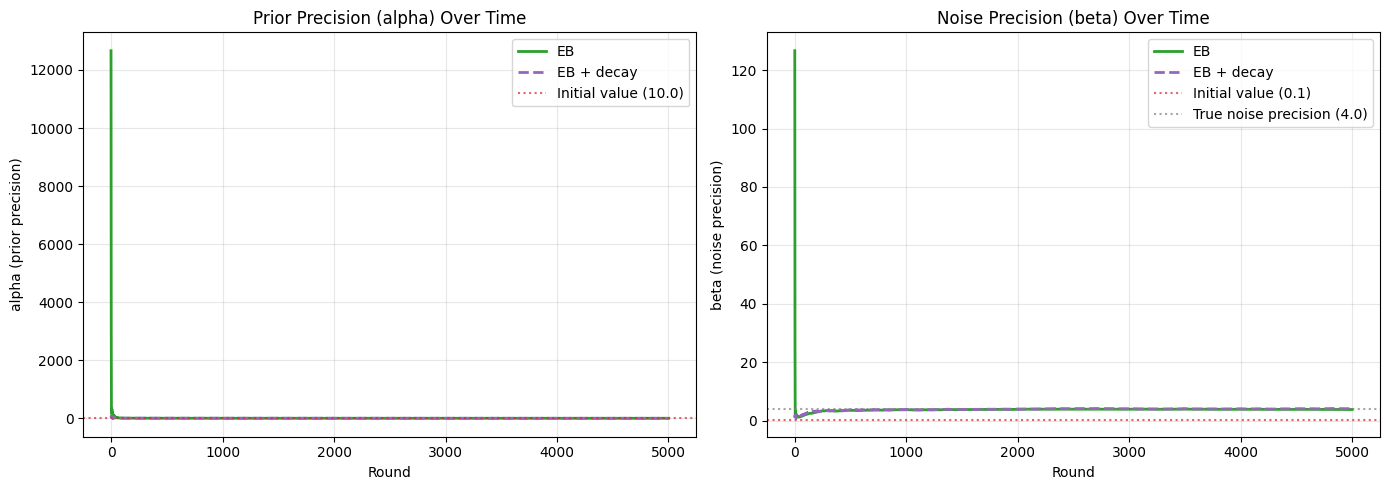

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eb_alpha_history, linewidth=2, color="C2", label="EB")
ax1.plot(eb_decay_alpha_history, linewidth=2, color="C4", linestyle="--", label="EB + decay")
ax1.axhline(y=10.0, color="C3", linestyle=":", alpha=0.7, label="Initial value (10.0)")
ax1.set_xlabel("Round")
ax1.set_ylabel("alpha (prior precision)")
ax1.set_title("Prior Precision (alpha) Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(eb_beta_history, linewidth=2, color="C2", label="EB")
ax2.plot(eb_decay_beta_history, linewidth=2, color="C4", linestyle="--", label="EB + decay")
ax2.axhline(y=0.1, color="C3", linestyle=":", alpha=0.7, label="Initial value (0.1)")
ax2.axhline(
    y=1.0 / TRUE_NOISE_STD**2,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label=f"True noise precision ({1.0 / TRUE_NOISE_STD**2:.1f})",
)
ax2.set_xlabel("Round")
ax2.set_ylabel("beta (noise precision)")
ax2.set_title("Noise Precision (beta) Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What to notice:**

- Both `alpha` traces drop rapidly from the initial value of 10.0 in the first few hundred rounds, then stabilize. The data-driven value is much lower than the misspecified starting point — the true coefficients are large enough that heavy regularization is harmful.
- Both `beta` traces climb from 0.1 toward the true noise precision of 4.0. They don't converge exactly to 4.0 because the MacKay update balances noise precision against model complexity (effective degrees of freedom), but they land in the right neighborhood.
- The **EB + decay** traces (dashed) closely track the no-decay traces. Decay slightly reduces the effective sample size, which can make the estimates a bit noisier, but the MacKay updates remain stable. This is the key result: decay doesn't destabilize the hyperparameter estimates.

## Discussion

### When to use `EmpiricalBayesNormalRegressor`

- **Unknown noise scale**: You don't know how noisy your rewards are (common in most real applications)
- **Unknown signal strength**: You don't know how large the true coefficients are, making it hard to set regularization
- **Sensitivity to hyperparameters**: Your problem is one where bad `alpha`/`beta` values lead to poor performance
- **No offline data for tuning**: You can't cross-validate hyperparameters before deployment

### When plain `NormalRegressor` suffices

- **Well-understood domains**: You have strong prior knowledge about the noise level and coefficient scales
- **Offline tuning available**: You can cross-validate `alpha` and `beta` on historical data before deploying the bandit
- **Computational budget is tight**: EB adds ~10 iterations per `partial_fit` call (the MacKay update). For most problems this overhead is negligible, but in extremely latency-sensitive applications it may matter

### Decay as a defensive default

In production, you rarely know whether the environment is truly stationary. User preferences shift, seasonal effects appear, and reward distributions drift. Setting `learning_rate < 1` (e.g. `0.999`) applies exponential decay to the precision matrix, down-weighting old observations so the model can adapt.

As this notebook shows, EB + decay performs comparably to EB without decay in the stationary case — the MacKay updates smoothly absorb the slightly wider posterior that decay induces. This makes `learning_rate=0.999` a sensible default: you pay very little in the stationary case and gain the ability to react if the environment shifts.

### Key takeaway

The empirical Bayes approach provides **robustness to hyperparameter misspecification** at minimal computational cost. Pairing it with a small decay rate gives you a second layer of robustness — against environmental change — without sacrificing hyperparameter tracking quality.